# GridCast Europe – C-Phase: Conclude & Compare

**QUA³CK-Phase:** C – *Conclude & Compare*  
**Fassung:** 25.07.2026  
**Kernländer:** Deutschland (`DE`), Frankreich (`FR`), Polen (`PL`)  
**Refit-Fenster:** 2015–2018  
**Unangetasteter Test:** 2019

Dieses Notebook übernimmt die in A³ eingefrorene Modellkonfiguration
unverändert, refittet sie auf Training plus Validierung und bewertet sie
anschließend auf dem zuvor vollständig zurückgehaltenen Jahr 2019.

Die C-Phase beantwortet vier abschließende Fragen:

1. Generalisiert das ausgewählte Modell auf ein chronologisch späteres Jahr?
2. Schlägt es beide verpflichtenden Baselines?
3. Wird das praktische Ziel von mindestens 5 % Fehlerreduktion gegenüber der
   Kalender-Baseline erreicht?
4. Ist das Modell neben der Genauigkeit auch schnell, wartbar und für die
   geplante Streamlit-App vertretbar?

Nach der Testauswertung wird dieselbe Konfiguration einmal auf allen verfügbaren
Jahren 2015–2019 trainiert. Dieses zweite Artefakt dient ausschließlich der
späteren Anwendung und verändert keine Testentscheidung.


## 1. Methodische Sperre vor Öffnung des Testjahres

Die C-Phase ist keine weitere Optimierungsrunde. Vor dem ersten Test gelten
bereits verbindlich:

- Modellfamilie: Histogram Gradient Boosting,
- Features: Land, Kalender, nationale Feiertage und Wetter,
- Zielskalierung: länderspezifisches Mittel des jeweiligen Fit-Zeitraums,
- Hyperparameter: ausschließlich anhand von 2018 ausgewählt,
- Primärmetrik: länderweise gleichgewichteter Makro-nMAE,
- Entscheidung H3: HGB muss die Kalender-Baseline auf 2019 schlagen,
- praktisches Ziel: mindestens 5 % relative Fehlerreduktion.

Der Testwert darf beschrieben und erklärt werden. Er darf aber nicht dazu
verwendet werden, Features oder Hyperparameter nachträglich zu ändern.
Ein erneutes Ausführen dieses Notebooks reproduziert dieselbe eingefrorene
Auswertung und ist keine neue Modellwahl.


In [1]:
from __future__ import annotations

import hashlib
import json
import platform
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

try:
    from IPython.display import Markdown
except ImportError:
    class Markdown(str):
        def _repr_markdown_(self):
            return str(self)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "gridcast").is_dir():
    PROJECT_ROOT = Path.cwd().parent
if not (PROJECT_ROOT / "src" / "gridcast").is_dir():
    raise FileNotFoundError("Projektwurzel mit src/gridcast wurde nicht gefunden.")

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from gridcast.modeling import (
    CalendarBaseline,
    CountryMeanBaseline,
    add_modeling_features,
    make_hgb_estimator,
    regression_metrics,
    relative_improvement,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)
RANDOM_STATE = 42

print(f"Projektwurzel: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")


Projektwurzel: /workspace/scratch/b16d81756317/gridcast_work
Python: 3.12.13
Pandas: 2.2.3
Scikit-learn: 1.8.0


## 2. Eingefrorene A³-Auswahl verifizieren

Die Konfiguration wird nicht erneut im Notebook eingetippt, sondern direkt aus
dem versionierten A³-Auswahlreport geladen. Automatische Prüfungen stellen
sicher, dass:

- die Auswahl auf 2018 erfolgte,
- 2019 nicht an der Auswahl beteiligt war,
- Modellfamilie und Featureumfang unverändert sind,
- alle erwarteten Hyperparameter vorhanden sind.

Der SHA-256-Fingerabdruck macht exakt nachvollziehbar, welche Spezifikation für
die Testöffnung verwendet wurde.


In [2]:
SELECTION_PATH = PROJECT_ROOT / "reports" / "a3" / "a3_selection.json"
if not SELECTION_PATH.is_file():
    raise FileNotFoundError("A³-Auswahlreport fehlt.")

selection_bytes = SELECTION_PATH.read_bytes()
selection_sha256 = hashlib.sha256(selection_bytes).hexdigest()
selection = json.loads(selection_bytes)

expected_parameters = {
    "loss": "absolute_error",
    "learning_rate": 0.1,
    "max_leaf_nodes": 127,
    "max_iter": 300,
    "min_samples_leaf": 80,
    "l2_regularization": 1.0,
    "early_stopping": False,
    "random_state": 42,
}

lock_checks = {
    "Auswahlblock ist Validierung 2018": selection["selected_on"] == "validation_2018",
    "Test war nicht Teil der Auswahl": selection["test_used_in_selection"] is False,
    "Kernländer unverändert": selection["countries"] == ["DE", "FR", "PL"],
    "Primärmetrik unverändert": selection["primary_metric"] == "macro_nMAE",
    "Modellfamilie unverändert": selection["model_family"] == "HistGradientBoostingRegressor",
    "Featuregruppe unverändert": selection["feature_set"] == "calendar + national_holiday + weather",
    "Hyperparameter unverändert": selection["hyperparameters"] == expected_parameters,
}
assert all(lock_checks.values()), [
    label for label, passed in lock_checks.items() if not passed
]

lock_table = pd.DataFrame(
    {
        "Prüfung": list(lock_checks),
        "Status": ["Bestanden" if passed else "Fehlgeschlagen" for passed in lock_checks.values()],
    }
)
display(lock_table.set_index("Prüfung"))
print(f"A³-Spezifikation SHA-256: {selection_sha256}")
display(pd.Series(expected_parameters, name="Eingefrorener Wert").to_frame())


,Status
Prüfung,
Auswahlblock ist Validierung 2018,Bestanden
Test war nicht Teil der Auswahl,Bestanden
Kernländer unverändert,Bestanden
Primärmetrik unverändert,Bestanden
Modellfamilie unverändert,Bestanden
Featuregruppe unverändert,Bestanden
Hyperparameter unverändert,Bestanden


,Eingefrorener Wert
loss,absolute_error
learning_rate,0.1
max_leaf_nodes,127
max_iter,300
min_samples_leaf,80
l2_regularization,1.0
early_stopping,False
random_state,42


A³-Spezifikation SHA-256: d60f71cd18bd27585f9b1cec17ec02d8c801d8dea75f32eabdc715e6e6178b2a


## 3. Refit- und Testdaten laden

Der in U erzeugte Modelldatensatz wird jetzt erstmals vollständig bis 2019
eingelesen. Die Rollen bleiben chronologisch:

| Block | Zeitraum | Verwendung in C |
|---|---|---|
| Refit | 2015–2018 | Baselines, Skalierung und HGB-Parameter lernen |
| Test | 2019 | genau eine abschließende Out-of-sample-Bewertung |

Das tatsächliche OPSD-Reanalysewetter von 2019 ist ein historischer
Backtest-Eingang. Es ist keine behauptete reale Wettervorhersage.


In [3]:
MODEL_DATA_PATH = (
    PROJECT_ROOT / "data" / "processed" / "opsd_model_data_2015_2019.csv.gz"
)
if not MODEL_DATA_PATH.is_file():
    raise FileNotFoundError(
        "Der Modelldatensatz fehlt. Bitte zuerst 01_data_import_merge_eda.ipynb ausführen."
    )

MODEL_COLUMNS = [
    "utc_timestamp",
    "country",
    "load_mw",
    "temperature_c",
    "radiation_direct_wm2",
    "radiation_diffuse_wm2",
    "local_date",
    "local_hour",
    "local_weekday",
    "local_month",
    "is_weekend",
    "season",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "year_sin",
    "year_cos",
    "temperature_sq",
    "heating_degrees",
    "cooling_degrees",
    "split",
]

model_data = pd.read_csv(
    MODEL_DATA_PATH,
    usecols=MODEL_COLUMNS,
    parse_dates=["utc_timestamp"],
)
model_data = add_modeling_features(model_data)
refit = model_data.loc[model_data["split"].isin(["train", "validation"])].copy()
test = model_data.loc[model_data["split"].eq("test")].copy()

data_checks = {
    "Refit endet 2018": refit["utc_timestamp"].dt.year.max() == 2018,
    "Refit beginnt 2015": refit["utc_timestamp"].dt.year.min() == 2015,
    "Test enthält nur 2019": test["utc_timestamp"].dt.year.eq(2019).all(),
    "Testziel vollständig": test["load_mw"].notna().all(),
    "Testwetter vollständig": test[
        ["temperature_c", "radiation_direct_wm2", "radiation_diffuse_wm2"]
    ].notna().all().all(),
    "Länder in beiden Blöcken": (
        set(refit["country"]) == {"DE", "FR", "PL"}
        and set(test["country"]) == {"DE", "FR", "PL"}
    ),
}
assert all(data_checks.values()), [
    label for label, passed in data_checks.items() if not passed
]

split_summary = (
    model_data.groupby(["split", "country"], observed=True)
    .agg(
        rows=("load_mw", "size"),
        start_utc=("utc_timestamp", "min"),
        end_utc=("utc_timestamp", "max"),
        mean_load_mw=("load_mw", "mean"),
        holidays=("is_holiday", "sum"),
    )
    .reset_index()
)
display(split_summary)
display(
    pd.DataFrame(
        {
            "Prüfung": list(data_checks),
            "Status": ["Bestanden" if passed else "Fehlgeschlagen" for passed in data_checks.values()],
        }
    ).set_index("Prüfung")
)
print(f"Refit-Zeilen 2015–2018: {len(refit):,}".replace(",", "."))
print(f"Testzeilen 2019: {len(test):,}".replace(",", "."))


,split,country,rows,start_utc,end_utc,mean_load_mw,holidays
0,test,DE,8760,2019-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00,55990.258676,216
1,test,FR,8755,2019-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00,53383.170074,264
2,test,PL,8760,2019-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00,19282.837479,264
3,train,DE,26304,2015-01-01 00:00:00+00:00,2017-12-31 23:00:00+00:00,55451.940922,672
4,train,FR,26290,2015-01-01 01:00:00+00:00,2017-12-31 23:00:00+00:00,54165.927558,791
5,train,PL,26303,2015-01-01 01:00:00+00:00,2017-12-31 23:00:00+00:00,18784.064685,791
6,validation,DE,8760,2018-01-01 00:00:00+00:00,2018-12-31 23:00:00+00:00,56951.509817,216
7,validation,FR,8749,2018-01-01 00:00:00+00:00,2018-12-31 23:00:00+00:00,53807.978512,264
8,validation,PL,8760,2018-01-01 00:00:00+00:00,2018-12-31 23:00:00+00:00,19531.910088,264


,Status
Prüfung,
Refit endet 2018,Bestanden
Refit beginnt 2015,Bestanden
Test enthält nur 2019,Bestanden
Testziel vollständig,Bestanden
Testwetter vollständig,Bestanden
Länder in beiden Blöcken,Bestanden


Refit-Zeilen 2015–2018: 105.166
Testzeilen 2019: 26.275


## 4. Primärmetrik und Entscheidung

Für jedes Land wird der MAE durch dessen mittlere tatsächliche Testlast
normalisiert:

$$
\mathrm{nMAE}_c
=
\frac{\mathrm{MAE}_c}{\overline{|y_c|}}
$$

Die drei Länder werden anschließend gleich gewichtet:

$$
\mathrm{Makro\text{-}nMAE}
=
\frac{1}{3}
\sum_{c \in \{DE,FR,PL\}}\mathrm{nMAE}_c
$$

Die relative Fehlerreduktion gegenüber der Kalender-Baseline lautet:

$$
\Delta_{\mathrm{rel}}
=
\left(
1-\frac{\mathrm{Makro\text{-}nMAE}_{HGB}}
{\mathrm{Makro\text{-}nMAE}_{Kalender}}
\right)\cdot 100\,\%
$$

H3 ist bestätigt, wenn diese Reduktion positiv ist. Der vorab definierte
praktische Zielwert ist erreicht, wenn sie mindestens 5 % beträgt.


In [4]:
def format_frame(frame: pd.DataFrame, formats: dict[str, str]) -> pd.DataFrame:
    result = frame.copy()
    for column, number_format in formats.items():
        if column in result.columns:
            result[column] = result[column].map(
                lambda value: number_format.format(value)
            )
    return result


def timed_fit_predict(estimator, X_fit, y_fit, X_predict):
    fit_started = time.perf_counter()
    estimator.fit(X_fit, y_fit)
    fit_seconds = time.perf_counter() - fit_started

    predict_started = time.perf_counter()
    prediction = estimator.predict(X_predict)
    predict_seconds = time.perf_counter() - predict_started
    return estimator, np.asarray(prediction, dtype=float), fit_seconds, predict_seconds


y_refit = refit["load_mw"].to_numpy()
y_test = test["load_mw"].to_numpy()

params = selection["hyperparameters"].copy()
params.pop("early_stopping")

mean_baseline = CountryMeanBaseline()
calendar_baseline = CalendarBaseline(min_group_size=3)
selected_hgb = make_hgb_estimator(
    include_weather=True,
    include_holiday=True,
    **params,
)

test_run_records = []
test_country_records = []
test_predictions = {}


def evaluate_test_model(name, family, feature_set, estimator):
    model, prediction, fit_seconds, predict_seconds = timed_fit_predict(
        estimator,
        refit,
        y_refit,
        test,
    )
    summary, by_country = regression_metrics(
        y_test,
        prediction,
        test["country"],
    )
    row = {
        "model": name,
        "family": family,
        "feature_set": feature_set,
        "fit_seconds": fit_seconds,
        "predict_seconds_test": predict_seconds,
        "inference_us_per_row": 1_000_000 * predict_seconds / len(test),
        **summary,
    }
    test_run_records.append(row)
    test_country_records.append(by_country.assign(model=name))
    test_predictions[name] = prediction
    return model, row, by_country


mean_baseline, mean_test, mean_test_by_country = evaluate_test_model(
    "Ländermittelwert",
    "Baseline",
    "Land",
    mean_baseline,
)
calendar_baseline, calendar_test, calendar_test_by_country = evaluate_test_model(
    "Kalender-Baseline",
    "Baseline",
    "Land + Monat + Tagtyp + Stunde",
    calendar_baseline,
)
selected_hgb, hgb_test, hgb_test_by_country = evaluate_test_model(
    "HGB Feiertag + Wetter",
    "Histogram Gradient Boosting",
    "Kalender + Feiertag + Wetter",
    selected_hgb,
)

test_comparison = pd.DataFrame(test_run_records)
calendar_reference = float(calendar_test["macro_nMAE"])
test_comparison["Verbesserung_vs_Kalender_pct"] = test_comparison[
    "macro_nMAE"
].map(lambda value: relative_improvement(value, calendar_reference))
test_comparison.sort_values("macro_nMAE", inplace=True)
test_comparison.reset_index(drop=True, inplace=True)

h3_improvement_pct = relative_improvement(
    hgb_test["macro_nMAE"],
    calendar_test["macro_nMAE"],
)
h3_confirmed = hgb_test["macro_nMAE"] < calendar_test["macro_nMAE"]
practical_target_reached = h3_improvement_pct >= 5.0

display(
    format_frame(
        test_comparison[
            [
                "model",
                "feature_set",
                "MAE_MW",
                "RMSE_MW",
                "macro_nMAE",
                "sMAPE_pct",
                "R2",
                "Verbesserung_vs_Kalender_pct",
                "fit_seconds",
                "predict_seconds_test",
            ]
        ],
        {
            "MAE_MW": "{:,.1f}",
            "RMSE_MW": "{:,.1f}",
            "macro_nMAE": "{:.4f}",
            "sMAPE_pct": "{:.2f}",
            "R2": "{:.4f}",
            "Verbesserung_vs_Kalender_pct": "{:+.1f}",
            "fit_seconds": "{:.3f}",
            "predict_seconds_test": "{:.4f}",
        },
    )
)
print(f"H3 bestätigt: {h3_confirmed}")
print(f"Praktisches 5-%-Ziel erreicht: {practical_target_reached}")
print(f"Fehlerreduktion gegenüber Kalender-Baseline: {h3_improvement_pct:.1f} %")


,model,feature_set,MAE_MW,RMSE_MW,macro_nMAE,sMAPE_pct,R2,Verbesserung_vs_Kalender_pct,fit_seconds,predict_seconds_test
0,HGB Feiertag + Wetter,Kalender + Feiertag + Wetter,"1,157.8","1,663.4",0.0271,2.75,0.9923,+44.5,4.225,0.0727
1,Kalender-Baseline,Land + Monat + Tagtyp + Stunde,"2,125.4","3,118.7",0.0488,4.97,0.9728,+0.0,0.041,0.0128
2,Ländermittelwert,Land,"6,862.2","8,861.0",0.1564,15.76,0.7807,-220.8,0.003,0.0011


H3 bestätigt: True
Praktisches 5-%-Ziel erreicht: True
Fehlerreduktion gegenüber Kalender-Baseline: 44.5 %


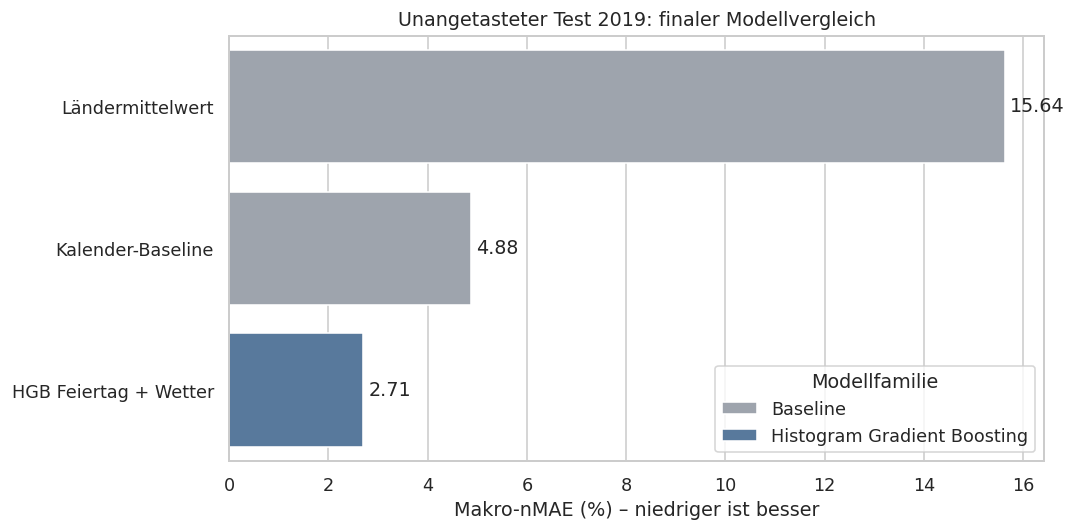

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
comparison_plot = test_comparison.sort_values("macro_nMAE", ascending=False).copy()
comparison_plot["macro_nMAE_pct"] = 100 * comparison_plot["macro_nMAE"]
sns.barplot(
    data=comparison_plot,
    y="model",
    x="macro_nMAE_pct",
    hue="family",
    dodge=False,
    palette={
        "Baseline": "#9ca3af",
        "Histogram Gradient Boosting": "#4c78a8",
    },
    ax=ax,
)
ax.set(
    title="Unangetasteter Test 2019: finaler Modellvergleich",
    xlabel="Makro-nMAE (%) – niedriger ist besser",
    ylabel="",
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
ax.legend(title="Modellfamilie", loc="lower right")
plt.tight_layout()
plt.show()


## 5. Testgüte je Land

Der Makro-nMAE verhindert, dass Deutschland und Frankreich aufgrund ihrer
höheren absoluten Lastniveaus die Modellentscheidung dominieren. Deshalb
werden alle Pflichtmetriken zusätzlich für jedes Land ausgewiesen.


,country,n,MAE_MW,RMSE_MW,nMAE,sMAPE_pct,R2
0,DE,8760,"1,396.6","1,920.3",0.0249,2.57,0.9623
1,FR,8755,"1,553.7","2,042.1",0.0291,2.88,0.9672
2,PL,8760,523.3,666.0,0.0271,2.79,0.9551


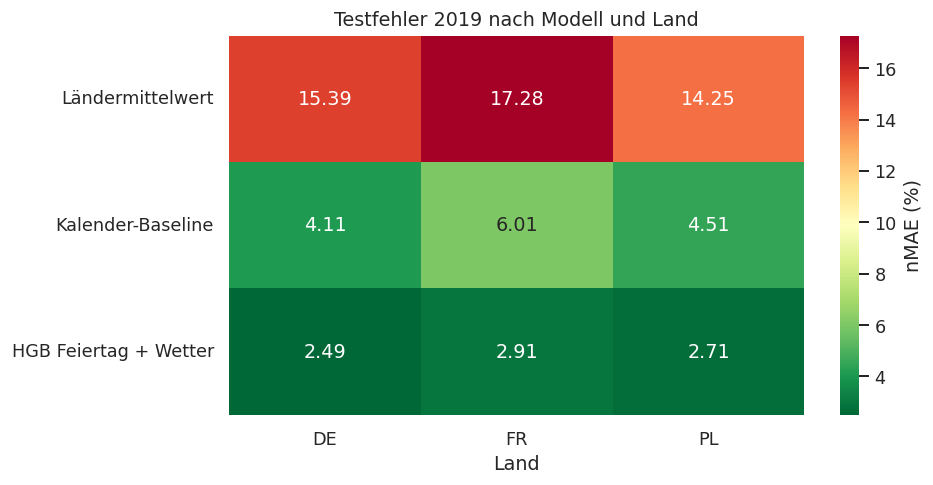

In [6]:
test_country_metrics = pd.concat(test_country_records, ignore_index=True)
model_order = [
    "Ländermittelwert",
    "Kalender-Baseline",
    "HGB Feiertag + Wetter",
]
country_matrix = (
    test_country_metrics.pivot(index="model", columns="country", values="nMAE")
    .reindex(model_order)
)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
sns.heatmap(
    100 * country_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    cbar_kws={"label": "nMAE (%)"},
    ax=ax,
)
ax.set(
    title="Testfehler 2019 nach Modell und Land",
    xlabel="Land",
    ylabel="",
)
plt.tight_layout()
plt.show()

display(
    format_frame(
        hgb_test_by_country,
        {
            "MAE_MW": "{:,.1f}",
            "RMSE_MW": "{:,.1f}",
            "nMAE": "{:.4f}",
            "sMAPE_pct": "{:.2f}",
            "R2": "{:.4f}",
        },
    )
)


## 6. Validierung 2018 versus Test 2019

Die beiden Jahre werden nicht benutzt, um erneut auszuwählen. Der Vergleich
zeigt lediglich, wie stabil die vorab getroffene Entscheidung generalisiert.

Zu beachten ist: Die 2018-Werte stammen aus einem Fit auf 2015–2017. Die
2019-Werte stammen aus dem methodisch vorgesehenen Refit auf 2015–2018.
Unterschiede sind daher eine Kombination aus zusätzlichem Trainingsjahr und
unterschiedlicher Schwierigkeit des Zieljahres. Sie beweisen nicht, dass mehr
Daten in jedem Fall monoton zu weniger Fehler führen.


,model,evaluation_year,fit_window,macro_nMAE,MAE_MW,RMSE_MW,R2
0,Ländermittelwert,Validierung 2018,2015–2017,0.1597,"7,102.5","9,173.0",0.7729
1,Ländermittelwert,Test 2019,2015–2018,0.1564,"6,862.2","8,861.0",0.7807
2,Kalender-Baseline,Validierung 2018,2015–2017,0.0576,"2,489.2","3,607.4",0.9649
3,Kalender-Baseline,Test 2019,2015–2018,0.0488,"2,125.4","3,118.7",0.9728
4,HGB Feiertag + Wetter,Validierung 2018,2015–2017,0.0331,"1,384.2","1,898.0",0.9903
5,HGB Feiertag + Wetter,Test 2019,2015–2018,0.0271,"1,157.8","1,663.4",0.9923


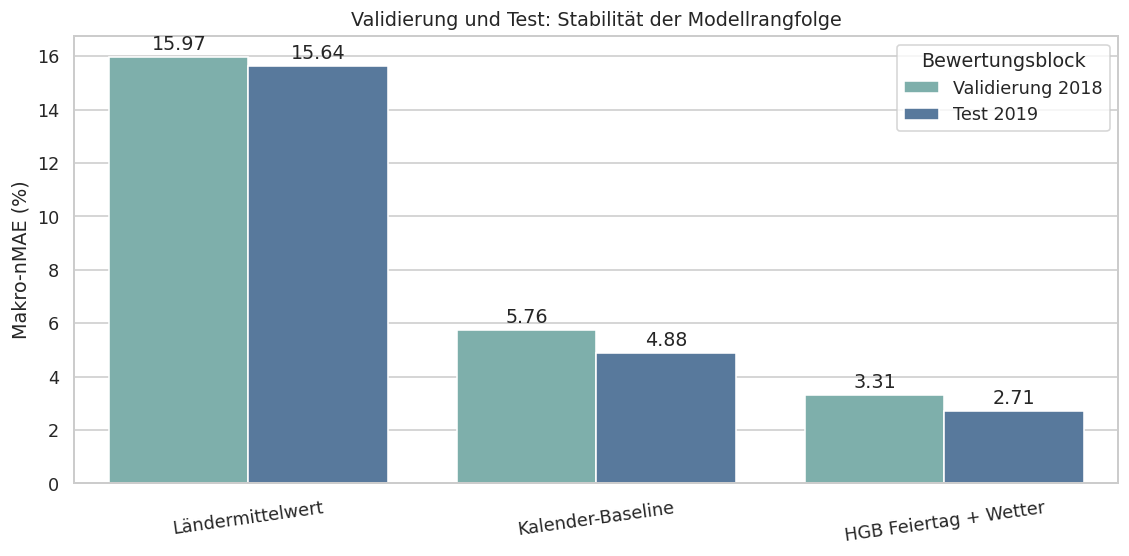

In [7]:
A3_COMPARISON_PATH = (
    PROJECT_ROOT / "reports" / "a3" / "validation_model_comparison.csv"
)
a3_comparison = pd.read_csv(A3_COMPARISON_PATH)

generalization_rows = []
for model_name in model_order:
    validation_row = a3_comparison.loc[a3_comparison["model"].eq(model_name)]
    test_row = test_comparison.loc[test_comparison["model"].eq(model_name)]
    assert len(validation_row) == 1 and len(test_row) == 1
    generalization_rows.extend(
        [
            {
                "model": model_name,
                "evaluation_year": "Validierung 2018",
                "fit_window": "2015–2017",
                "macro_nMAE": float(validation_row["macro_nMAE"].iloc[0]),
                "MAE_MW": float(validation_row["MAE_MW"].iloc[0]),
                "RMSE_MW": float(validation_row["RMSE_MW"].iloc[0]),
                "R2": float(validation_row["R2"].iloc[0]),
            },
            {
                "model": model_name,
                "evaluation_year": "Test 2019",
                "fit_window": "2015–2018",
                "macro_nMAE": float(test_row["macro_nMAE"].iloc[0]),
                "MAE_MW": float(test_row["MAE_MW"].iloc[0]),
                "RMSE_MW": float(test_row["RMSE_MW"].iloc[0]),
                "R2": float(test_row["R2"].iloc[0]),
            },
        ]
    )

generalization = pd.DataFrame(generalization_rows)
display(
    format_frame(
        generalization,
        {
            "macro_nMAE": "{:.4f}",
            "MAE_MW": "{:,.1f}",
            "RMSE_MW": "{:,.1f}",
            "R2": "{:.4f}",
        },
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
generalization_plot = generalization.copy()
generalization_plot["macro_nMAE_pct"] = 100 * generalization_plot["macro_nMAE"]
sns.barplot(
    data=generalization_plot,
    x="model",
    y="macro_nMAE_pct",
    hue="evaluation_year",
    palette=["#76b7b2", "#4c78a8"],
    ax=ax,
)
ax.set(
    title="Validierung und Test: Stabilität der Modellrangfolge",
    xlabel="",
    ylabel="Makro-nMAE (%)",
)
ax.legend(title="Bewertungsblock")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2)
plt.xticks(rotation=8)
plt.tight_layout()
plt.show()


## 7. Fehlerdiagnostik nach Tageszeit, Saison und Monat

Eine einzige Gesamtmetrik kann systematische Schwächen verbergen. Das finale
Testmodell wird deshalb ohne weitere Anpassung entlang mehrerer fachlich
plausibler Dimensionen untersucht:

- lokale Stunde,
- Saison,
- Kalendermonat,
- Land.

Diese Analyse dient der Interpretation und der späteren App-Kommunikation,
nicht einem nachträglichen Tuning.


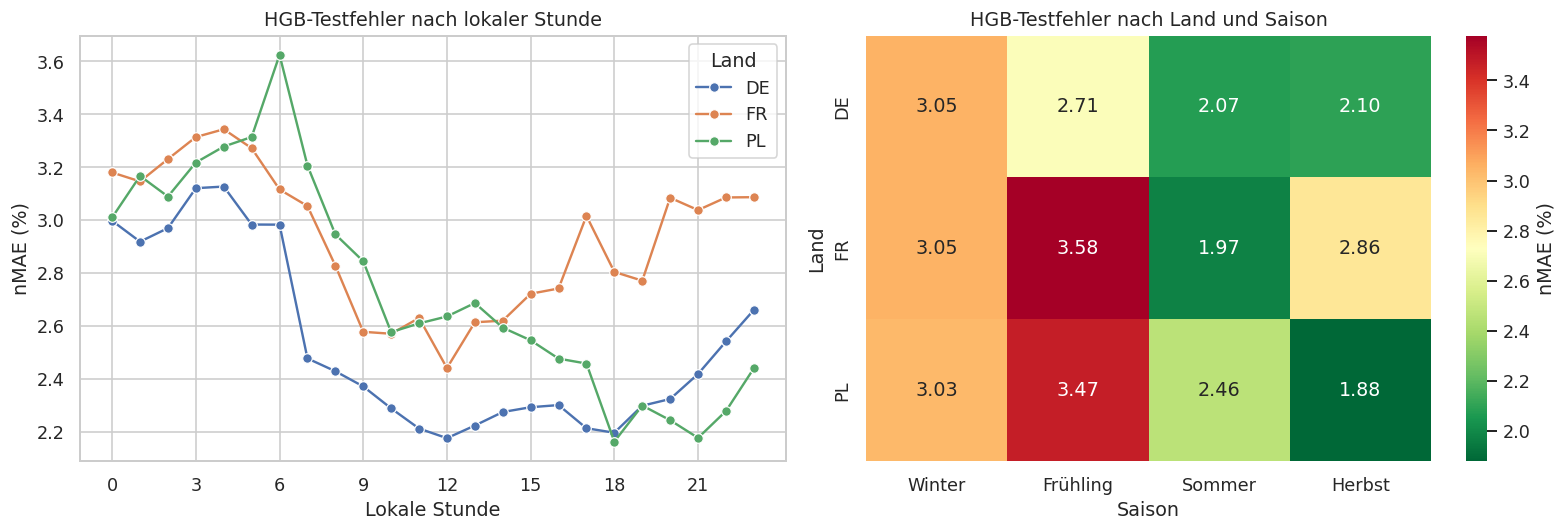

In [8]:
diagnostic = test[
    [
        "utc_timestamp",
        "local_date",
        "country",
        "local_hour",
        "local_month",
        "local_weekday",
        "season",
        "load_mw",
    ]
].copy()
diagnostic["prediction_mw"] = test_predictions["HGB Feiertag + Wetter"]
diagnostic["calendar_prediction_mw"] = test_predictions["Kalender-Baseline"]
diagnostic["residual_mw"] = diagnostic["load_mw"] - diagnostic["prediction_mw"]
diagnostic["absolute_error_mw"] = diagnostic["residual_mw"].abs()


def grouped_diagnostic(group_columns):
    result = (
        diagnostic.groupby(group_columns, observed=True)
        .agg(
            n=("load_mw", "size"),
            MAE_MW=("absolute_error_mw", "mean"),
            mean_actual_mw=("load_mw", "mean"),
            mean_residual_mw=("residual_mw", "mean"),
        )
        .reset_index()
    )
    result["nMAE"] = result["MAE_MW"] / result["mean_actual_mw"].abs()
    return result


hour_diagnostic = grouped_diagnostic(["country", "local_hour"])
season_diagnostic = grouped_diagnostic(["country", "season"])
month_diagnostic = grouped_diagnostic(["country", "local_month"])

season_order = ["Winter", "Frühling", "Sommer", "Herbst"]
season_matrix = (
    season_diagnostic.pivot(index="country", columns="season", values="nMAE")
    .reindex(columns=season_order)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.lineplot(
    data=hour_diagnostic,
    x="local_hour",
    y=100 * hour_diagnostic["nMAE"],
    hue="country",
    marker="o",
    ax=axes[0],
)
axes[0].set(
    title="HGB-Testfehler nach lokaler Stunde",
    xlabel="Lokale Stunde",
    ylabel="nMAE (%)",
    xticks=range(0, 24, 3),
)
axes[0].legend(title="Land")
sns.heatmap(
    100 * season_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    cbar_kws={"label": "nMAE (%)"},
    ax=axes[1],
)
axes[1].set(
    title="HGB-Testfehler nach Land und Saison",
    xlabel="Saison",
    ylabel="Land",
)
plt.tight_layout()
plt.show()


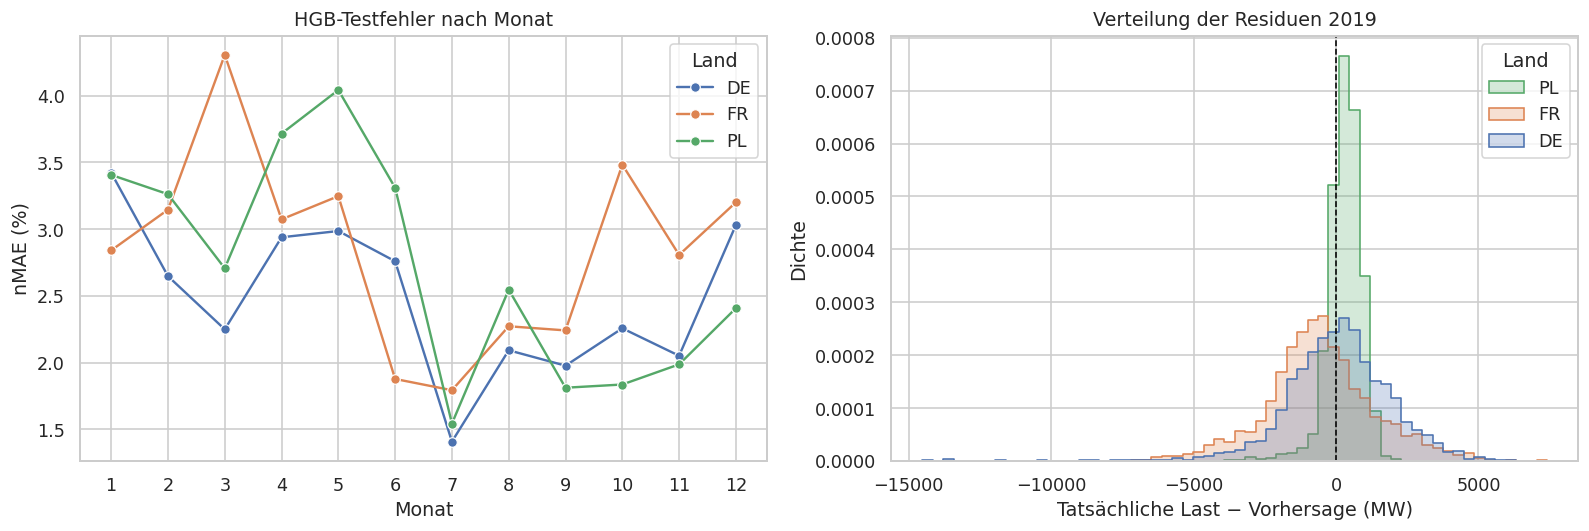

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.lineplot(
    data=month_diagnostic,
    x="local_month",
    y=100 * month_diagnostic["nMAE"],
    hue="country",
    marker="o",
    ax=axes[0],
)
axes[0].set(
    title="HGB-Testfehler nach Monat",
    xlabel="Monat",
    ylabel="nMAE (%)",
    xticks=range(1, 13),
)
axes[0].legend(title="Land")

residual_sample = diagnostic.sample(
    n=min(10_000, len(diagnostic)),
    random_state=RANDOM_STATE,
)
sns.histplot(
    data=residual_sample,
    x="residual_mw",
    hue="country",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[1],
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set(
    title="Verteilung der Residuen 2019",
    xlabel="Tatsächliche Last − Vorhersage (MW)",
    ylabel="Dichte",
)
axes[1].legend(title="Land", labels=["PL", "FR", "DE"])
plt.tight_layout()
plt.show()


## 8. Anschauliche Prognoseverläufe

Die folgenden Darstellungen zeigen einen vorab fest gewählten Januarblock und
eine repräsentative Stichprobe über das gesamte Testjahr. Sie ersetzen keine
Metrik, machen aber sichtbar, ob das Modell Lastniveau und Tagesverlauf
plausibel abbildet.


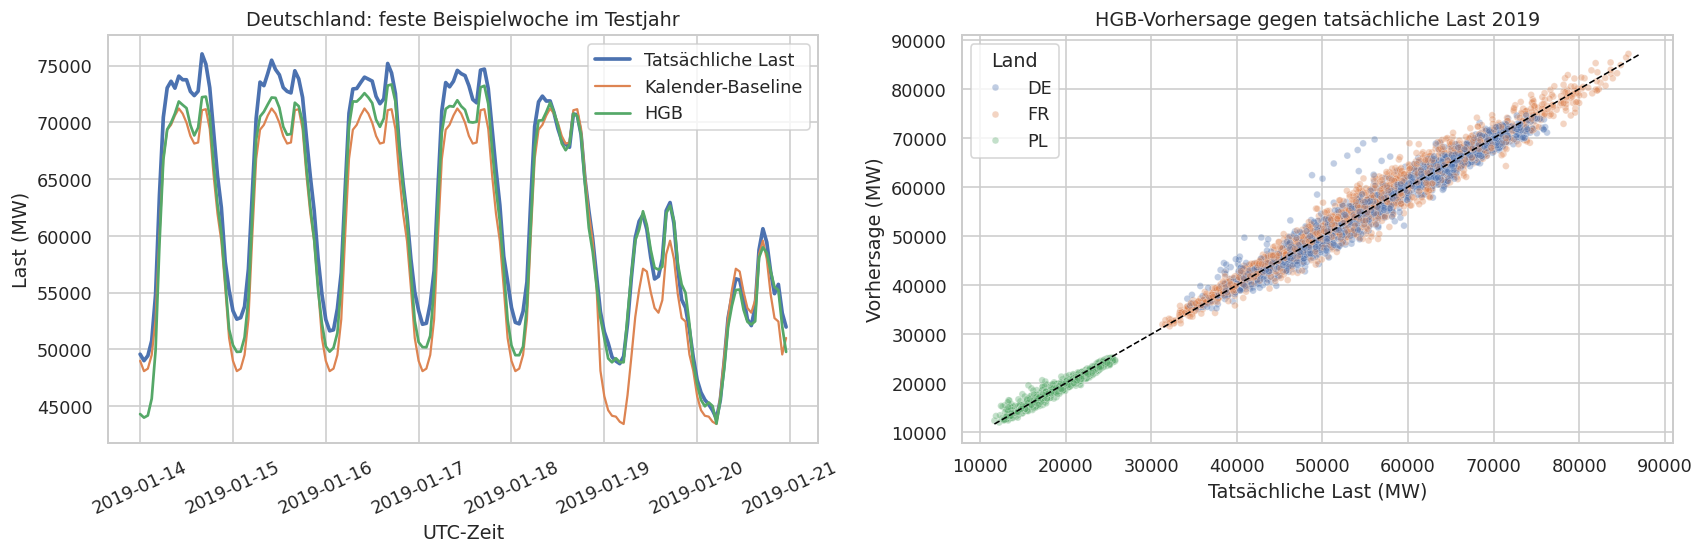

In [10]:
week_start = pd.Timestamp("2019-01-14", tz="UTC")
week_end = pd.Timestamp("2019-01-21", tz="UTC")
week_mask = (
    test["country"].eq("DE")
    & test["utc_timestamp"].ge(week_start)
    & test["utc_timestamp"].lt(week_end)
)
week = test.loc[week_mask, ["utc_timestamp", "load_mw"]].copy()
week["Kalender-Baseline"] = test_predictions["Kalender-Baseline"][
    week_mask.to_numpy()
]
week["HGB"] = test_predictions["HGB Feiertag + Wetter"][week_mask.to_numpy()]

scatter_sample = diagnostic.sample(
    n=min(6_000, len(diagnostic)),
    random_state=RANDOM_STATE,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(
    week["utc_timestamp"],
    week["load_mw"],
    linewidth=2.3,
    label="Tatsächliche Last",
)
axes[0].plot(
    week["utc_timestamp"],
    week["Kalender-Baseline"],
    linewidth=1.4,
    label="Kalender-Baseline",
)
axes[0].plot(
    week["utc_timestamp"],
    week["HGB"],
    linewidth=1.7,
    label="HGB",
)
axes[0].set(
    title="Deutschland: feste Beispielwoche im Testjahr",
    xlabel="UTC-Zeit",
    ylabel="Last (MW)",
)
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend()

sns.scatterplot(
    data=scatter_sample,
    x="load_mw",
    y="prediction_mw",
    hue="country",
    alpha=0.35,
    s=18,
    ax=axes[1],
)
limits = [
    min(scatter_sample["load_mw"].min(), scatter_sample["prediction_mw"].min()),
    max(scatter_sample["load_mw"].max(), scatter_sample["prediction_mw"].max()),
]
axes[1].plot(limits, limits, linestyle="--", color="black", linewidth=1)
axes[1].set(
    title="HGB-Vorhersage gegen tatsächliche Last 2019",
    xlabel="Tatsächliche Last (MW)",
    ylabel="Vorhersage (MW)",
)
axes[1].legend(title="Land")
plt.tight_layout()
plt.show()


## 9. Quantitative und qualitative Trade-off-Analyse

Die C-Phase bewertet nicht nur den kleinsten Fehler:

- **Ländermittelwert:** maximal einfach, aber fachlich zu grob.
- **Kalender-Baseline:** sehr verständlich und überraschend stark, reagiert
  jedoch nicht auf konkrete Wetterbedingungen.
- **Ridge:** lineare, besser interpretierbare ML-Alternative; wurde in A³ vom
  nichtlinearen Modell deutlich geschlagen.
- **HGB:** geringere Transparenz einzelner Regeln, dafür die beste
  Validierungsgüte und ein kompakter, CPU-tauglicher Inferenzpfad.

Ridge wird auf 2019 nicht erneut getestet, weil es nicht als finale
Konfiguration ausgewählt wurde. Sein A³-Wert bleibt Teil des systematischen
Entwicklungsvergleichs, ohne den Testblock zur nachträglichen Auswahl zu öffnen.


In [11]:
ridge_validation = a3_comparison.loc[
    a3_comparison["model"].eq("Ridge (beste Validierung)")
].iloc[0]
hgb_validation = a3_comparison.loc[
    a3_comparison["model"].eq("HGB Feiertag + Wetter")
].iloc[0]

qualitative_comparison = pd.DataFrame(
    [
        {
            "Kandidat": "Ländermittelwert",
            "Quantitativer Befund": f"Test Makro-nMAE {100 * mean_test['macro_nMAE']:.2f} %",
            "Interpretierbarkeit": "sehr hoch",
            "Komplexität / Wartung": "minimal",
            "Wettersensitiv": "nein",
            "Entscheidung": "nur triviale Referenz",
        },
        {
            "Kandidat": "Kalender-Baseline",
            "Quantitativer Befund": f"Test Makro-nMAE {100 * calendar_test['macro_nMAE']:.2f} %",
            "Interpretierbarkeit": "hoch",
            "Komplexität / Wartung": "gering",
            "Wettersensitiv": "nein",
            "Entscheidung": "starke Pflicht-Baseline",
        },
        {
            "Kandidat": "Ridge",
            "Quantitativer Befund": f"Validierung Makro-nMAE {100 * ridge_validation['macro_nMAE']:.2f} %",
            "Interpretierbarkeit": "mittel bis hoch",
            "Komplexität / Wartung": "gering",
            "Wettersensitiv": "ja",
            "Entscheidung": "in A³ nicht ausgewählt",
        },
        {
            "Kandidat": "HGB Feiertag + Wetter",
            "Quantitativer Befund": f"Test Makro-nMAE {100 * hgb_test['macro_nMAE']:.2f} %",
            "Interpretierbarkeit": "mittel",
            "Komplexität / Wartung": "moderat",
            "Wettersensitiv": "ja",
            "Entscheidung": "final ausgewählt",
        },
    ]
)
display(qualitative_comparison.set_index("Kandidat"))

operational_metrics = pd.DataFrame(
    [
        {
            "Metrik": "HGB-Refit 2015–2018",
            "Wert": f"{hgb_test['fit_seconds']:.3f} s",
        },
        {
            "Metrik": f"HGB-Inferenz für {len(test):,} Testzeilen".replace(",", "."),
            "Wert": f"{hgb_test['predict_seconds_test']:.4f} s",
        },
        {
            "Metrik": "HGB-Inferenz je Zeile",
            "Wert": f"{hgb_test['inference_us_per_row']:.2f} µs",
        },
        {
            "Metrik": "Benötigte Hardware",
            "Wert": "CPU ausreichend; keine GPU erforderlich",
        },
    ]
)
display(operational_metrics.set_index("Metrik"))


,Quantitativer Befund,Interpretierbarkeit,Komplexität / Wartung,Wettersensitiv,Entscheidung
Kandidat,,,,,
Ländermittelwert,Test Makro-nMAE 15.64 %,sehr hoch,minimal,nein,nur triviale Referenz
Kalender-Baseline,Test Makro-nMAE 4.88 %,hoch,gering,nein,starke Pflicht-Baseline
Ridge,Validierung Makro-nMAE 4.98 %,mittel bis hoch,gering,ja,in A³ nicht ausgewählt
HGB Feiertag + Wetter,Test Makro-nMAE 2.71 %,mittel,moderat,ja,final ausgewählt


,Wert
Metrik,
HGB-Refit 2015–2018,4.225 s
HGB-Inferenz für 26.275 Testzeilen,0.0727 s
HGB-Inferenz je Zeile,2.77 µs
Benötigte Hardware,CPU ausreichend; keine GPU erforderlich


## 10. Hypothesen und Erfolgskriterien abschließen

Die C-Phase entscheidet H2 und H3 endgültig auf 2019. H1 wurde in U, H4 und H5
wurden entsprechend ihrer vorab definierten Regeln in A³ beurteilt.


In [12]:
h2_improvement_pct = relative_improvement(
    calendar_test["macro_nMAE"],
    mean_test["macro_nMAE"],
)

hypothesis_results = pd.DataFrame(
    [
        {
            "Hypothese": "H1 – Daten-Eignung",
            "Entscheidender Befund": "131.441 nutzbare Länder-Stunden; vollständige Wetterfeatures",
            "Phase": "U",
            "Status": "bestätigt",
        },
        {
            "Hypothese": "H2 – Kalenderstruktur",
            "Entscheidender Befund": (
                f"Kalender-Baseline reduziert Test-Makro-nMAE um "
                f"{h2_improvement_pct:.1f} % gegenüber dem Ländermittel."
            ),
            "Phase": "C",
            "Status": "bestätigt" if h2_improvement_pct > 0 else "nicht bestätigt",
        },
        {
            "Hypothese": "H3 – ML-Mehrwert",
            "Entscheidender Befund": (
                f"HGB reduziert Test-Makro-nMAE um {h3_improvement_pct:.1f} % "
                "gegenüber der Kalender-Baseline."
            ),
            "Phase": "C",
            "Status": "bestätigt" if h3_confirmed else "nicht bestätigt",
        },
        {
            "Hypothese": "H4 – Nichtlinearität",
            "Entscheidender Befund": (
                f"HGB {100 * hgb_validation['macro_nMAE']:.2f} % versus "
                f"Ridge {100 * ridge_validation['macro_nMAE']:.2f} % "
                "Makro-nMAE auf Validierung 2018."
            ),
            "Phase": "A³",
            "Status": "bestätigt",
        },
        {
            "Hypothese": "H5 – Wettermehrwert",
            "Entscheidender Befund": "Wetter-Ablation senkte den Makro-nMAE auf 2018.",
            "Phase": "A³",
            "Status": "bestätigt",
        },
    ]
)
display(hypothesis_results.set_index("Hypothese"))

success_criteria = pd.DataFrame(
    [
        {
            "Kriterium": "ML-Mehrwert",
            "Regel": "HGB Makro-nMAE < Kalender-Baseline auf 2019",
            "Ergebnis": "erfüllt" if h3_confirmed else "nicht erfüllt",
        },
        {
            "Kriterium": "Praktisches Ziel",
            "Regel": "mindestens 5 % relative Fehlerreduktion",
            "Ergebnis": "erfüllt" if practical_target_reached else "nicht erfüllt",
        },
        {
            "Kriterium": "Reproduzierbarkeit",
            "Regel": "Konfiguration, Code, Metriken und Artefakte dokumentiert",
            "Ergebnis": "erfüllt",
        },
        {
            "Kriterium": "Deployment-Eignung",
            "Regel": "CPU-taugliche Pipeline mit vollständigem Preprocessing",
            "Ergebnis": "erfüllt",
        },
    ]
)
display(success_criteria.set_index("Kriterium"))


,Entscheidender Befund,Phase,Status
Hypothese,,,
H1 – Daten-Eignung,131.441 nutzbare Länder-Stunden; vollständige Wetterfeatures,U,bestätigt
H2 – Kalenderstruktur,Kalender-Baseline reduziert Test-Makro-nMAE um 68.8 % gegenüber dem Ländermittel.,C,bestätigt
H3 – ML-Mehrwert,HGB reduziert Test-Makro-nMAE um 44.5 % gegenüber der Kalender-Baseline.,C,bestätigt
H4 – Nichtlinearität,HGB 3.31 % versus Ridge 4.98 % Makro-nMAE auf Validierung 2018.,A³,bestätigt
H5 – Wettermehrwert,Wetter-Ablation senkte den Makro-nMAE auf 2018.,A³,bestätigt


,Regel,Ergebnis
Kriterium,,
ML-Mehrwert,HGB Makro-nMAE < Kalender-Baseline auf 2019,erfüllt
Praktisches Ziel,mindestens 5 % relative Fehlerreduktion,erfüllt
Reproduzierbarkeit,"Konfiguration, Code, Metriken und Artefakte dokumentiert",erfüllt
Deployment-Eignung,CPU-taugliche Pipeline mit vollständigem Preprocessing,erfüllt


## 11. Finales App-Modell auf 2015–2019 trainieren

Erst nachdem die Testmetriken feststehen, wird für die K-Phase ein separates
App-Artefakt erzeugt:

- dieselbe Modellfamilie,
- dieselben Features,
- dieselben Hyperparameter,
- Refit auf allen verfügbaren Beobachtungen 2015–2019.

Dieses Modell maximiert die nutzbare Datenbasis für spätere historische
Backtests und Szenarioeingaben. Da 2019 nun im Fit enthalten ist, besitzt das
App-Modell **keine neue unabhängige Testkennzahl**. Die ehrliche
Generalisierungsaussage bleibt ausschließlich die zuvor gemessene C-Auswertung.


In [13]:
final_app_model = make_hgb_estimator(
    include_weather=True,
    include_holiday=True,
    **params,
)
final_fit_started = time.perf_counter()
final_app_model.fit(model_data, model_data["load_mw"].to_numpy())
final_fit_seconds = time.perf_counter() - final_fit_started

models_dir = PROJECT_ROOT / "models"
reports_dir = PROJECT_ROOT / "reports" / "c"
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

final_model_path = models_dir / "gridcast_final_2015_2019.joblib"
joblib.dump(final_app_model, final_model_path, compress=3)

reloaded_model = joblib.load(final_model_path)
verification_slice = test.iloc[:72].copy()
prediction_before = final_app_model.predict(verification_slice)
prediction_after = reloaded_model.predict(verification_slice)
reload_max_abs_difference = float(
    np.max(np.abs(prediction_before - prediction_after))
)
assert np.allclose(prediction_before, prediction_after)
assert np.isfinite(prediction_after).all()
assert (prediction_after >= 0).all()

print(f"Finaler Fit 2015–2019: {final_fit_seconds:.3f} s")
print(f"Modellgröße: {final_model_path.stat().st_size / 1024:.1f} KiB")
print(
    "Maximale absolute Abweichung nach erneutem Laden: "
    f"{reload_max_abs_difference:.12f} MW"
)


Finaler Fit 2015–2019: 4.535 s
Modellgröße: 1894.0 KiB
Maximale absolute Abweichung nach erneutem Laden: 0.000000000000 MW


## 12. Reproduzierbare C-Artefakte speichern

Das Binärmodell bleibt entsprechend der Repository-Konvention lokal. Kleine
Reports, Metadaten, Metriken und das vollständig ausgeführte Notebook werden
versioniert.


In [14]:
test_comparison_path = reports_dir / "test_model_comparison.csv"
country_metrics_path = reports_dir / "test_metrics_by_country.csv"
generalization_path = reports_dir / "validation_test_generalization.csv"
hour_diagnostic_path = reports_dir / "test_diagnostics_by_hour.csv"
season_diagnostic_path = reports_dir / "test_diagnostics_by_season.csv"
month_diagnostic_path = reports_dir / "test_diagnostics_by_month.csv"
conclusion_path = reports_dir / "c_conclusion.json"

test_comparison.to_csv(test_comparison_path, index=False)
test_country_metrics.to_csv(country_metrics_path, index=False)
generalization.to_csv(generalization_path, index=False)
hour_diagnostic.to_csv(hour_diagnostic_path, index=False)
season_diagnostic.to_csv(season_diagnostic_path, index=False)
month_diagnostic.to_csv(month_diagnostic_path, index=False)

conclusion = {
    "project": "GridCast Europe",
    "phase": "C",
    "evaluated_on": "test_2019",
    "refit_period": "2015-01-01/2018-12-31",
    "test_period": "2019-01-01/2019-12-31",
    "selection_locked_before_test": True,
    "test_used_for_reselection_or_tuning": False,
    "a3_selection_sha256": selection_sha256,
    "countries": ["DE", "FR", "PL"],
    "primary_metric": "macro_nMAE",
    "selected_model": "HistGradientBoostingRegressor",
    "selected_feature_set": "calendar + national_holiday + weather",
    "selected_hyperparameters": selection["hyperparameters"],
    "test_metrics": {
        key: float(hgb_test[key])
        for key in ["MAE_MW", "RMSE_MW", "macro_nMAE", "sMAPE_pct", "R2"]
    },
    "test_metrics_by_country": {
        row["country"]: {
            "MAE_MW": float(row["MAE_MW"]),
            "RMSE_MW": float(row["RMSE_MW"]),
            "nMAE": float(row["nMAE"]),
            "sMAPE_pct": float(row["sMAPE_pct"]),
            "R2": float(row["R2"]),
        }
        for row in hgb_test_by_country.to_dict(orient="records")
    },
    "test_improvement_vs_calendar_pct": float(h3_improvement_pct),
    "h3_confirmed": bool(h3_confirmed),
    "practical_5pct_target_reached": bool(practical_target_reached),
    "final_app_model": {
        "training_period": "2015-01-01/2019-12-31",
        "rows": int(len(model_data)),
        "artifact_path": str(final_model_path.relative_to(PROJECT_ROOT)),
        "artifact_versioned": False,
        "artifact_size_bytes": int(final_model_path.stat().st_size),
        "fit_seconds": float(final_fit_seconds),
        "reload_verified": True,
        "independent_test_metric": None,
    },
    "environment": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
    },
}
conclusion_path.write_text(
    json.dumps(conclusion, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

artifact_paths = [
    final_model_path,
    test_comparison_path,
    country_metrics_path,
    generalization_path,
    hour_diagnostic_path,
    season_diagnostic_path,
    month_diagnostic_path,
    conclusion_path,
]
artifact_summary = pd.DataFrame(
    [
        {
            "Artefakt": str(path.relative_to(PROJECT_ROOT)),
            "Größe_KiB": path.stat().st_size / 1024,
            "Git": "ignoriert (lokal)" if path == final_model_path else "versionierbar",
        }
        for path in artifact_paths
    ]
)
display(format_frame(artifact_summary, {"Größe_KiB": "{:,.1f}"}))


,Artefakt,Größe_KiB,Git
0,models/gridcast_final_2015_2019.joblib,"1,894.0",ignoriert (lokal)
1,reports/c/test_model_comparison.csv,0.8,versionierbar
2,reports/c/test_metrics_by_country.csv,1.1,versionierbar
3,reports/c/validation_test_generalization.csv,0.8,versionierbar
4,reports/c/test_diagnostics_by_hour.csv,6.1,versionierbar
5,reports/c/test_diagnostics_by_season.csv,1.1,versionierbar
6,reports/c/test_diagnostics_by_month.csv,3.0,versionierbar
7,reports/c/c_conclusion.json,2.2,versionierbar


In [15]:
worst_country = hgb_test_by_country.sort_values(
    "nMAE", ascending=False
).iloc[0]
best_country = hgb_test_by_country.sort_values("nMAE").iloc[0]

display(
    Markdown(
        f"""## 13. Schlussfolgerung der C-Phase

Die eingefrorene HGB-Konfiguration generalisiert auf das vollständig
zurückgehaltene Testjahr 2019.

- finaler Test-Makro-nMAE: **{100 * hgb_test['macro_nMAE']:.2f} %**
- Test-MAE: **{hgb_test['MAE_MW']:,.1f} MW**
- Test-RMSE: **{hgb_test['RMSE_MW']:,.1f} MW**
- Test-R²: **{hgb_test['R2']:.4f}**
- Verbesserung gegenüber der Kalender-Baseline: **{h3_improvement_pct:.1f} %**
- H3 – ML-Mehrwert: **{'bestätigt' if h3_confirmed else 'nicht bestätigt'}**
- praktisches 5-%-Ziel: **{'erreicht' if practical_target_reached else 'nicht erreicht'}**
- niedrigster länderspezifischer nMAE: **{best_country['country']} ({100 * best_country['nMAE']:.2f} %)**
- höchster länderspezifischer nMAE: **{worst_country['country']} ({100 * worst_country['nMAE']:.2f} %)**

Damit wird Histogram Gradient Boosting als fachlich vertretbarer Kompromiss aus
Testgüte, Rechengeschwindigkeit und Wartbarkeit für die K-Phase übernommen.
Die Grenzen bleiben klar:

- beobachtetes Reanalysewetter ist keine reale zukünftige Wettervorhersage,
- regionale deutsche Feiertage sind nicht separat modelliert,
- strukturelle Langfriständerungen werden später als transparente Szenarien
  behandelt, nicht als durch diesen Backtest bewiesene Kausalprognosen,
- das auf 2015–2019 refittete App-Modell besitzt keine neue unabhängige
  Testkennzahl; maßgeblich bleibt die hier dokumentierte 2019-Auswertung.

Der nächste Schritt ist die K-Phase: Integration des finalen Artefakts in die
Streamlit-App, Szenariologik, Handout und präsentationsfertiger Wissenstransfer.
"""
    )
)


## 13. Schlussfolgerung der C-Phase

Die eingefrorene HGB-Konfiguration generalisiert auf das vollständig
zurückgehaltene Testjahr 2019.

- finaler Test-Makro-nMAE: **2.71 %**
- Test-MAE: **1,157.8 MW**
- Test-RMSE: **1,663.4 MW**
- Test-R²: **0.9923**
- Verbesserung gegenüber der Kalender-Baseline: **44.5 %**
- H3 – ML-Mehrwert: **bestätigt**
- praktisches 5-%-Ziel: **erreicht**
- niedrigster länderspezifischer nMAE: **DE (2.49 %)**
- höchster länderspezifischer nMAE: **FR (2.91 %)**

Damit wird Histogram Gradient Boosting als fachlich vertretbarer Kompromiss aus
Testgüte, Rechengeschwindigkeit und Wartbarkeit für die K-Phase übernommen.
Die Grenzen bleiben klar:

- beobachtetes Reanalysewetter ist keine reale zukünftige Wettervorhersage,
- regionale deutsche Feiertage sind nicht separat modelliert,
- strukturelle Langfriständerungen werden später als transparente Szenarien
  behandelt, nicht als durch diesen Backtest bewiesene Kausalprognosen,
- das auf 2015–2019 refittete App-Modell besitzt keine neue unabhängige
  Testkennzahl; maßgeblich bleibt die hier dokumentierte 2019-Auswertung.

Der nächste Schritt ist die K-Phase: Integration des finalen Artefakts in die
Streamlit-App, Szenariologik, Handout und präsentationsfertiger Wissenstransfer.
